# Master of Data Science at UBCO — DATA589
# Lab 2 — Convolutional Neural Networks and Object Detection with YOLO

**Course:** DATA589 Applied Computer Vision and Deep Learning  
**Level:** Master's  
**Topic:** CNN architecture, feature maps, object detection concepts, and custom YOLO training  
**Estimated time:** 2–3 hours  
**Recommended platform:** **Google Colab (GPU required)**

---

## Why this lab?

In **Lecture 3**, you learned:
- how **convolutional layers** extract spatial features using filters,
- the role of **ReLU**, **pooling**, **stride**, and **padding**,
- how feature map spatial dimensions are computed,
- the evolution from **R-CNN → Faster R-CNN → YOLO** for object detection,
- why YOLO is fast: single forward pass, no region proposals.

This lab anchors that theory in code: you will build and train a CNN classifier,
implement the key detection metrics, and train/evaluate a YOLO model on a
Roboflow dataset.

---

> **Submission:** Run all cells top-to-bottom, keep all outputs visible,
> and submit your completed `.ipynb` file.


## Learning Outcomes

By the end of this lab, you should be able to:
- compute output spatial dimensions after Conv2d and MaxPool2d layers,
- build and train a CNN classifier in PyTorch,
- interpret loss/accuracy curves and a confusion matrix,
- implement IoU and understand precision/recall/mAP,
- organise a dataset in YOLO format and write a `data.yaml` file,
- train and evaluate a YOLOv8 detector on a custom dataset.


---

# PART A — Setup

## Part A.0 — Install and Import


Run the cell below to install dependencies and import all libraries needed for this lab.

> **Note:** On Google Colab, PyTorch and torchvision are pre-installed.
> Only `ultralytics` needs installing.


In [ ]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)


In [ ]:
# Install Ultralytics (YOLOv8)
#!pip install -q ultralytics==8.3.0 mismatching library

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device  :', device)
print('PyTorch :', torch.__version__)

if device.type == 'cpu':
    print('\n⚠  No GPU detected. Go to Runtime → Change runtime type → GPU.')


Device  : cuda
PyTorch : 2.10.0+cu128


---

# PART B — CNN Architecture and Classification

## Part B.1 — Concept Check

Before writing any model, make sure you can answer these questions from Lecture 3.

**Question 1:** If we have a 32×32 RGB image and apply 64 filters of size 3×3
(no padding, stride 1), what is the output shape?  
The formula from the lecture:

$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

**Your answer:** `Output shape: 30 × 30 × 64`

---

**Question 2:** Pooling layers have learnable parameters — True or False?  
Explain in one sentence.

**Your answer:**

False, pooling layers do not have learnable parameters (weights and biases) that are updated via backpropagation. A pooling layer is just a rule applied to a convolutional layer to reduce size.

---

**Question 3:** What does a ReLU activation do to a feature map, and why is
it necessary between convolutional layers?

**Your answer:**

ReLU sets negative values in a feature map to zero, and positive values are left unchanged. ReLU is necessary between convolutional layers because otherwise stacking convolutional layers would just be many linear operations, which is equivalent to a single linear layer. This would limit models to learning simple patterns.


## Part B.2 — Spatial Dimension Calculator

Complete the function below so that it computes the spatial output size of a
`Conv2d` or `MaxPool2d` layer.

$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$


In [ ]:
def conv_output_size(h_in: int, kernel: int, stride: int = 1, padding: int = 0) -> int:
    """Return the 1-D output size after a Conv2d or MaxPool2d."""
    # TODO: implement the formula from Lecture 3
    h_out =  np.floor((h_in + 2*padding - kernel) / stride) + 1
    return h_out


# ── Tests ─────────────────────────────────────────────────────────────────────
# Conv(k=3, s=1, p=1) on 32  →  should give 32
print('Conv (k=3,s=1,p=1) on 32 :', conv_output_size(32, kernel=3, stride=1, padding=1))

# MaxPool(k=2, s=2) on 32    →  should give 16
print('MaxPool(k=2,s=2)   on 32 :', conv_output_size(32, kernel=2, stride=2, padding=0))

# Conv(k=5, s=1, p=0) on 32  →  should give 28
print('Conv (k=5,s=1,p=0) on 32 :', conv_output_size(32, kernel=5, stride=1, padding=0))


Conv (k=3,s=1,p=1) on 32 : 32.0
MaxPool(k=2,s=2)   on 32 : 16.0
Conv (k=5,s=1,p=0) on 32 : 28.0


## Part B.4 — Build a CNN Classifier

Implement the `CNN` class using `nn.Module`.

**Architecture requirements:**
1. `self.features`: three convolutional blocks (Conv → ReLU → Pool), matching
   the trace table above. Use `AdaptiveAvgPool2d((1,1))` in the final block.
2. `self.classifier`: `Flatten → Linear(128→256) → ReLU → Dropout(0.3) → Linear(256→num_classes)`.
3. A `forward()` method that passes input through both.


In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()

        # ── Feature Extraction ────────────────────────────────────────────────
        # TODO: define self.features as nn.Sequential with:
        #   Block 1: Conv2d(3→32,  k=3, p=1), ReLU, MaxPool2d(2)
        #   Block 2: Conv2d(32→64, k=3, p=1), ReLU, MaxPool2d(2)
        #   Block 3: Conv2d(64→128,k=3, p=1), ReLU, AdaptiveAvgPool2d((1,1))
        self.features = nn.Sequential(
            # ... TODO ...
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )

        # ── Classifier Head ───────────────────────────────────────────────────
        # TODO: define self.classifier as nn.Sequential with:
        #   Flatten, Linear(128→256), ReLU, Dropout(0.3), Linear(256→num_classes)
        self.classifier = nn.Sequential(
            # ... TODO ...
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: pass x through features then classifier
        x = self.features(x)
        x = self.classifier(x)
        return x


# ── Sanity check ──────────────────────────────────────────────────────────────
model   = CNN(num_classes=10)
dummy   = torch.zeros(2, 3, 32, 32)   # batch of 2 CIFAR-10 images
out     = model(dummy)
print('Output shape:', out.shape)     # expected: torch.Size([2, 10])
assert out.shape == (2, 10), 'Shape mismatch — check your architecture'
print('Architecture check passed ✓')


Output shape: torch.Size([2, 10])
Architecture check passed ✓


## Part B.5 — Load CIFAR-10

We train on **CIFAR-10**: 60,000 colour images (32×32) across 10 classes.
Data augmentation (random flip, random crop) is applied to the **training set only**.


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

train_ds = datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
test_ds  = datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = train_ds.classes
print('Classes :', CLASSES)
print('Train   :', len(train_ds), 'images')
print('Test    :', len(test_ds),  'images')


100%|██████████| 170M/170M [00:16<00:00, 10.4MB/s]


Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train   : 50000 images
Test    : 10000 images


### Task B.5.1 — Visualise a Batch

Display a **4×8 grid** of 32 sample images from the training set with their class labels.
Remember to denormalise before displaying.


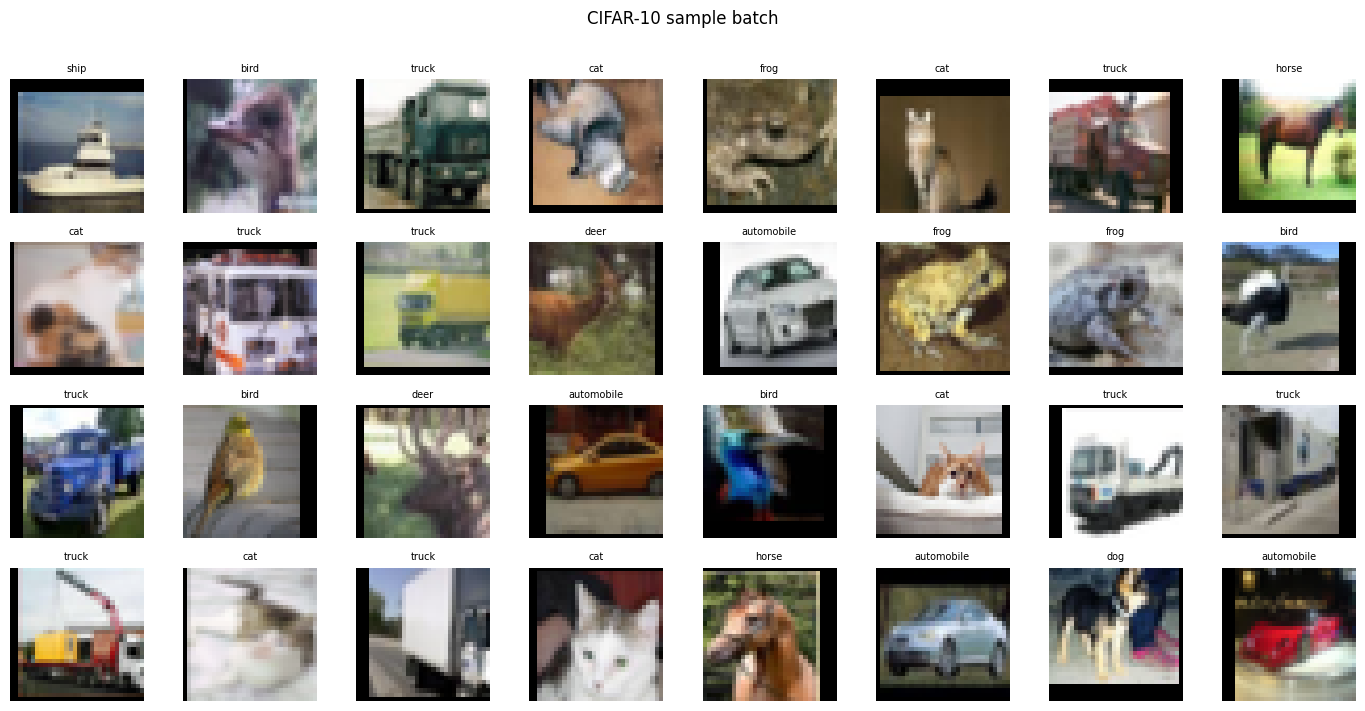

In [ ]:
# Denormalise helper
MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
STD  = torch.tensor([0.2470, 0.2435, 0.2616])

def denorm(t):
    return (t * STD[:, None, None] + MEAN[:, None, None]).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for ax, img, lbl in zip(axes.flatten(), images[:32], labels[:32]):
    ax.imshow(denorm(img).permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[lbl], fontsize=7)
    ax.axis('off')
plt.suptitle('CIFAR-10 sample batch', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## Part B.6 — Training and Evaluation Loop

Complete the two functions below:
- `train_one_epoch` — forward pass, compute loss, backpropagate, update weights.
- `evaluate` — forward pass only (no gradients), collect predictions for metrics.


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # TODO: zero gradients
        optimizer.zero_grad()

        # TODO: forward pass
        logits = model(x)

        # TODO: compute loss
        loss = criterion(logits, y)

        # TODO: backward pass and optimizer step
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_y, all_p = [], []
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == y).sum().item()
        total      += y.size(0)
        all_y.extend(y.cpu().numpy())
        all_p.extend(preds.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_y), np.array(all_p)


## Part B.7 — Train the CNN


In [ ]:
model     = CNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

NUM_EPOCHS = 5
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc                  = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc, y_true, y_pred  = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(tr_loss);  history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss);   history['test_acc'].append(te_acc)

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')


Epoch  1/5  train_loss=1.8806  train_acc=0.2801  test_loss=1.6472  test_acc=0.3742
Epoch  2/5  train_loss=1.6236  train_acc=0.3824  test_loss=1.5435  test_acc=0.4164
Epoch  3/5  train_loss=1.4865  train_acc=0.4423  test_loss=1.4143  test_acc=0.4825
Epoch  4/5  train_loss=1.3770  train_acc=0.4908  test_loss=1.3006  test_acc=0.5215
Epoch  5/5  train_loss=1.2886  train_acc=0.5299  test_loss=1.2170  test_acc=0.5504


## Part B.8 — Plot Learning Curves and Confusion Matrix


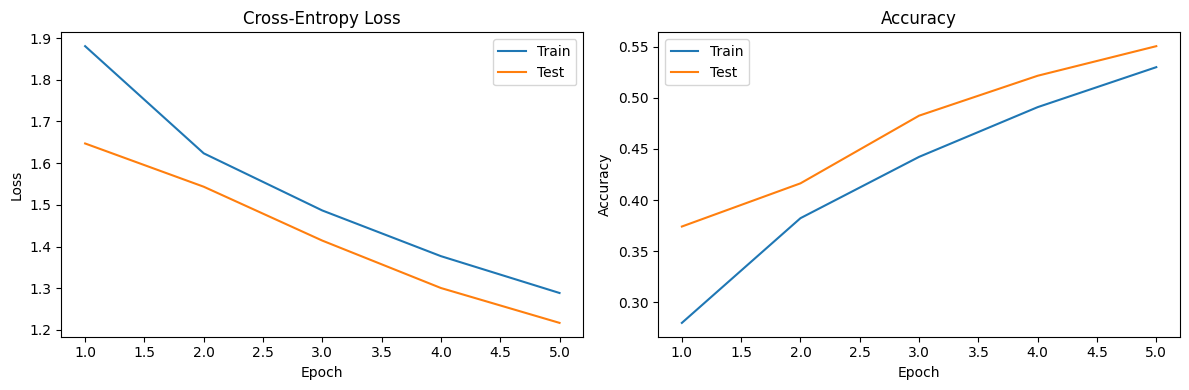

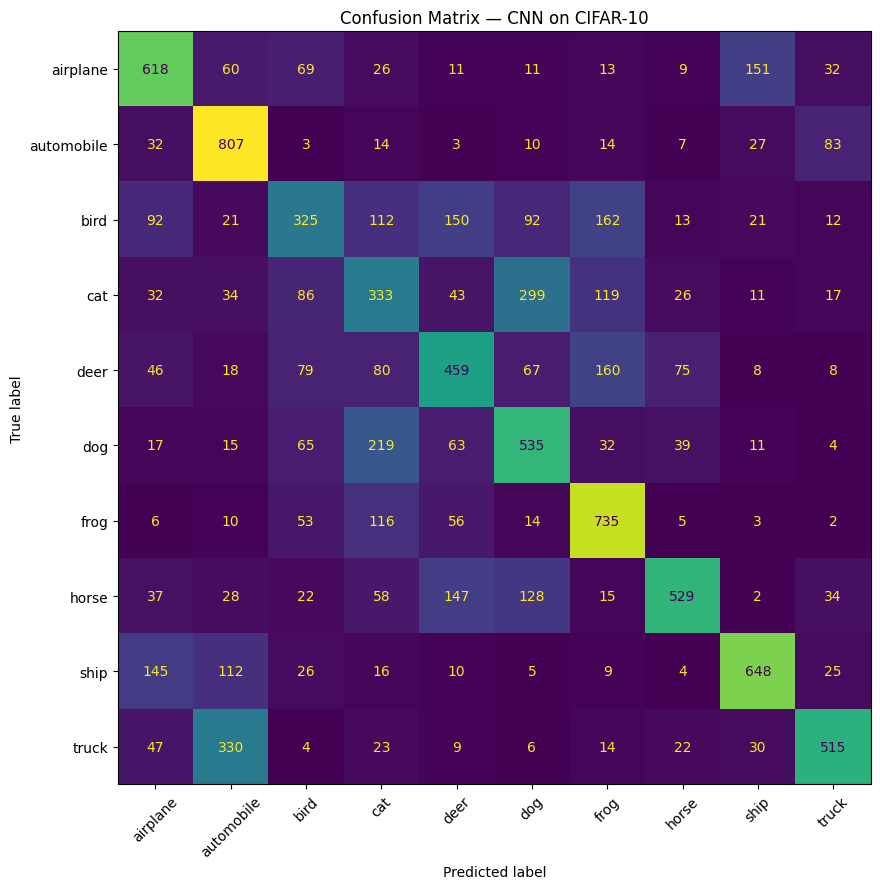

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['test_loss'],  label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss'); axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['test_acc'],  label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()

# Confusion matrix
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Confusion Matrix — CNN on CIFAR-10')
plt.tight_layout(); plt.show()


### Reflection B.8

1. Identify **one pair of classes** most frequently confused. Why?
2. Describe the loss curve pattern — is the model overfitting or underfitting?

**Your answers:**

1. The pair of classes most frequently confused are dogs and cats. This makes sense because cats and dogs have many similar features: 4 legs, a tail, 2 forward-facing eyes, sharp teeth, and more. All this leads to cats and dogs having more alike visually than they do with other objects like automobiles, ships, and trucks.
2. The train line is slightly higher loss than the test line, and both lines trend downward, although, the slope decreases as epoch increases. Since the slope of the test line is still negative at the last epoch, the model can still be improved with more training, so the model is underfitting.

---

# PART C — Object Detection Concepts

## Part C.1 — Bounding Boxes and IoU

Object detectors predict bounding boxes. The standard overlap metric is
**Intersection over Union (IoU)**:

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

A common threshold is **IoU ≥ 0.5** to declare a detection a True Positive.


In [ ]:
def compute_iou(box_a: list, box_b: list) -> float:
    """
    Compute IoU between two boxes in [x1, y1, x2, y2] format.

    Parameters
    ----------
    box_a, box_b : [x1, y1, x2, y2]  (pixel coordinates, top-left → bottom-right)

    Returns
    -------
    iou : float in [0, 1]
    """
    # TODO: compute intersection rectangle
    inter_x1 = max(box_a[0], box_b[0])
    inter_y1 = max(box_a[1], box_b[1])
    inter_x2 = min(box_a[2], box_b[2])
    inter_y2 = min(box_a[3], box_b[3])

    # TODO: intersection area (must be ≥ 0)
    inter_area = max(0,inter_x2-inter_x1)*max(0, inter_y2 - inter_y1)

    # TODO: union area
    area_a = (box_a[2]-box_a[0])*(box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0])*(box_b[3]-box_b[1])
    union_area = area_a+area_b-inter_area

    # TODO: return IoU (guard against division by zero)
    return inter_area / union_area if union_area > 0 else 0.0


# ── Tests ─────────────────────────────────────────────────────────────────────
assert abs(compute_iou([0,0,4,4], [0,0,4,4]) - 1.0) < 1e-6, 'Identical boxes should be 1.0'
assert compute_iou([0,0,2,2], [3,3,5,5]) == 0.0,            'Non-overlapping should be 0.0'

iou = compute_iou([0,0,4,4], [2,0,6,4])   # expected ≈ 0.3333
print(f'Half-overlap IoU: {iou:.4f}  (expected ≈ 0.3333)')
assert abs(iou - 1/3) < 1e-4
print('All IoU tests passed ✓')


Half-overlap IoU: 0.3333  (expected ≈ 0.3333)
All IoU tests passed ✓


## Part C.3 — Precision, Recall, and mAP

| Metric | Formula | Meaning |
|--------|---------|--------|
| Precision | TP / (TP + FP) | Of all detections, what fraction is correct? |
| Recall    | TP / (TP + FN) | Of all GT objects, what fraction did we find? |
| AP@50     | Area under PR curve at IoU ≥ 0.5 | Per-class detection quality |
| mAP@50    | Mean AP across all classes | Overall detection quality |

### Task C.3 — Compute TP / FP / FN

Given four detections and 4 ground-truth boxes (IoU threshold = 0.5):

| Detection | IoU with nearest GT | Conf |
|-----------|---------------------|------|
| Det 1     | 0.82                | 0.91 |
| Det 2     | 0.45                | 0.78 |
| Det 3     | 0.76                | 0.65 |
| Det 4     | 0.10                | 0.55 |

Each GT box can only be matched once.


In [ ]:
detections    = [
    {'iou': 0.82, 'conf': 0.91},
    {'iou': 0.45, 'conf': 0.78},
    {'iou': 0.76, 'conf': 0.65},
    {'iou': 0.10, 'conf': 0.55},
]
num_gt        = 4
iou_threshold = 0.5

# TODO: compute TP, FP, FN, Precision, Recall
TP = sum(1 for d in detections if d['iou'] >= iou_threshold)   # detections where iou >= threshold
FP = sum(1 for d in detections if d['iou'] < iou_threshold)   # detections where iou <  threshold
FN = num_gt - TP   # GT boxes not matched by any detection

precision = TP/(TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP/(TP + FN) if (TP + FN) > 0 else 0.0

print(f'TP        : {TP}')
print(f'FP        : {FP}')
print(f'FN        : {FN}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')


TP        : 2
FP        : 2
FN        : 2
Precision : 0.5000
Recall    : 0.5000


---

# PART D — Prepare a Custom Dataset for YOLO

## Part D.1 — YOLO Dataset Format

YOLO expects the following structure:

```
custom_data/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/    ← one .txt per image, same filename stem
│   ├── val/
│   └── test/
└── data.yaml
```

Each label file row: `<class_id>  <x_center>  <y_center>  <width>  <height>`  
All values are **normalised to [0, 1]** relative to image dimensions.

## Part D.2 — Download a Dataset from Roboflow

1. Go to [roboflow.com/universe](https://universe.roboflow.com) and pick any public dataset.
2. Click **Download** → Format: **YOLOv8** → **Show download code**.
3. Copy the `pip install roboflow` + Python snippet and paste it into the cell below.
4. Make sure `DATA_ROOT` matches the folder Roboflow creates.

> **Suggested datasets:** *COCO128*, *Playing Cards*, *Hard Hat Workers*, *Fruit Detection*.


In [ ]:
# TODO: paste your Roboflow download snippet here.
# It should look similar to:
#
!pip install roboflow -q
from roboflow import Roboflow
rf = Roboflow(api_key='ALeR6WyTEHFjWzdWwrnD')
project = rf.workspace("team-roboflow").project("coco-128")
dataset = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
# After downloading, set DATA_ROOT to the dataset folder:
import yaml
from pathlib import Path
DATA_ROOT = Path(dataset.location)   # e.g. Path('playing-cards-1')
assert DATA_ROOT.exists(), f'Dataset folder not found: {DATA_ROOT}'
print('Dataset root:', DATA_ROOT.resolve())

with open(DATA_ROOT / "data.yaml", 'r') as f:
    data = yaml.safe_load(f)

# Update CLASS_NAMES to match your dataset
CLASS_NAMES = data['names']
print("Classes:", CLASS_NAMES)

Dataset root: /content/COCO-128-2
Classes: ['aeroplane', 'backpack', 'banana', 'baseball bat', 'baseball glove', 'bear', 'bed', 'bench', 'bicycle', 'bird', 'boat', 'book', 'bottle', 'bowl', 'broccoli', 'bus', 'cake', 'car', 'carrot', 'cat', 'cell phone', 'chair', 'clock', 'cup', 'diningtable', 'dog', 'donut', 'elephant', 'fork', 'frisbee', 'giraffe', 'handbag', 'horse', 'hot dog', 'kite', 'knife', 'laptop', 'microwave', 'motorbike', 'mouse', 'orange', 'oven', 'person', 'pizza', 'pottedplant', 'refrigerator', 'remote', 'sandwich', 'scissors', 'sink', 'skateboard', 'skis', 'snowboard', 'sofa', 'spoon', 'sports ball', 'stop sign', 'suitcase', 'teddy bear', 'tennis racket', 'tie', 'toilet', 'toothbrush', 'traffic light', 'train', 'truck', 'tvmonitor', 'umbrella', 'vase', 'wine glass', 'zebra']


## Part D.3 — Verify Dataset Structure


In [ ]:
#this doesnt match the robolflow directory
for split in ['train', 'val', 'test']:
    imgs   = list((DATA_ROOT / 'images' / split).glob('*.jpg'))
    labels = list((DATA_ROOT / 'labels' / split).glob('*.txt'))
    print(f'{split:6s}  images={len(imgs):4d}  labels={len(labels):4d}')

print()
print('data.yaml:')
print((DATA_ROOT / 'data.yaml').read_text())


train   images=   0  labels=   0
val     images=   0  labels=   0
test    images=   0  labels=   0

data.yaml:
names:
- aeroplane
- backpack
- banana
- baseball bat
- baseball glove
- bear
- bed
- bench
- bicycle
- bird
- boat
- book
- bottle
- bowl
- broccoli
- bus
- cake
- car
- carrot
- cat
- cell phone
- chair
- clock
- cup
- diningtable
- dog
- donut
- elephant
- fork
- frisbee
- giraffe
- handbag
- horse
- hot dog
- kite
- knife
- laptop
- microwave
- motorbike
- mouse
- orange
- oven
- person
- pizza
- pottedplant
- refrigerator
- remote
- sandwich
- scissors
- sink
- skateboard
- skis
- snowboard
- sofa
- spoon
- sports ball
- stop sign
- suitcase
- teddy bear
- tennis racket
- tie
- toilet
- toothbrush
- traffic light
- train
- truck
- tvmonitor
- umbrella
- vase
- wine glass
- zebra
nc: 71
roboflow:
  license: CC BY 4.0
  project: coco-128
  url: https://universe.roboflow.com/team-roboflow/coco-128/dataset/2
  version: 2
  workspace: team-roboflow
test: ../test/images
train: 

In [ ]:
#use this instead
import cv2

for split_dir in ['train', 'valid', 'test']: # Note: Roboflow often names validation 'valid'
    imgs   = list((DATA_ROOT / split_dir / 'images').glob('*.jpg'))
    labels = list((DATA_ROOT / split_dir / 'labels').glob('*.txt'))
    print(f'{split_dir:6s}  images={len(imgs):4d}  labels={len(labels):4d}')

print()
print('data.yaml:')
print((DATA_ROOT / 'data.yaml').read_text())

train   images= 128  labels= 128
valid   images= 123  labels= 123
test    images= 127  labels= 127

data.yaml:
names:
- aeroplane
- backpack
- banana
- baseball bat
- baseball glove
- bear
- bed
- bench
- bicycle
- bird
- boat
- book
- bottle
- bowl
- broccoli
- bus
- cake
- car
- carrot
- cat
- cell phone
- chair
- clock
- cup
- diningtable
- dog
- donut
- elephant
- fork
- frisbee
- giraffe
- handbag
- horse
- hot dog
- kite
- knife
- laptop
- microwave
- motorbike
- mouse
- orange
- oven
- person
- pizza
- pottedplant
- refrigerator
- remote
- sandwich
- scissors
- sink
- skateboard
- skis
- snowboard
- sofa
- spoon
- sports ball
- stop sign
- suitcase
- teddy bear
- tennis racket
- tie
- toilet
- toothbrush
- traffic light
- train
- truck
- tvmonitor
- umbrella
- vase
- wine glass
- zebra
nc: 71
roboflow:
  license: CC BY 4.0
  project: coco-128
  url: https://universe.roboflow.com/team-roboflow/coco-128/dataset/2
  version: 2
  workspace: team-roboflow
test: ../test/images
train: 

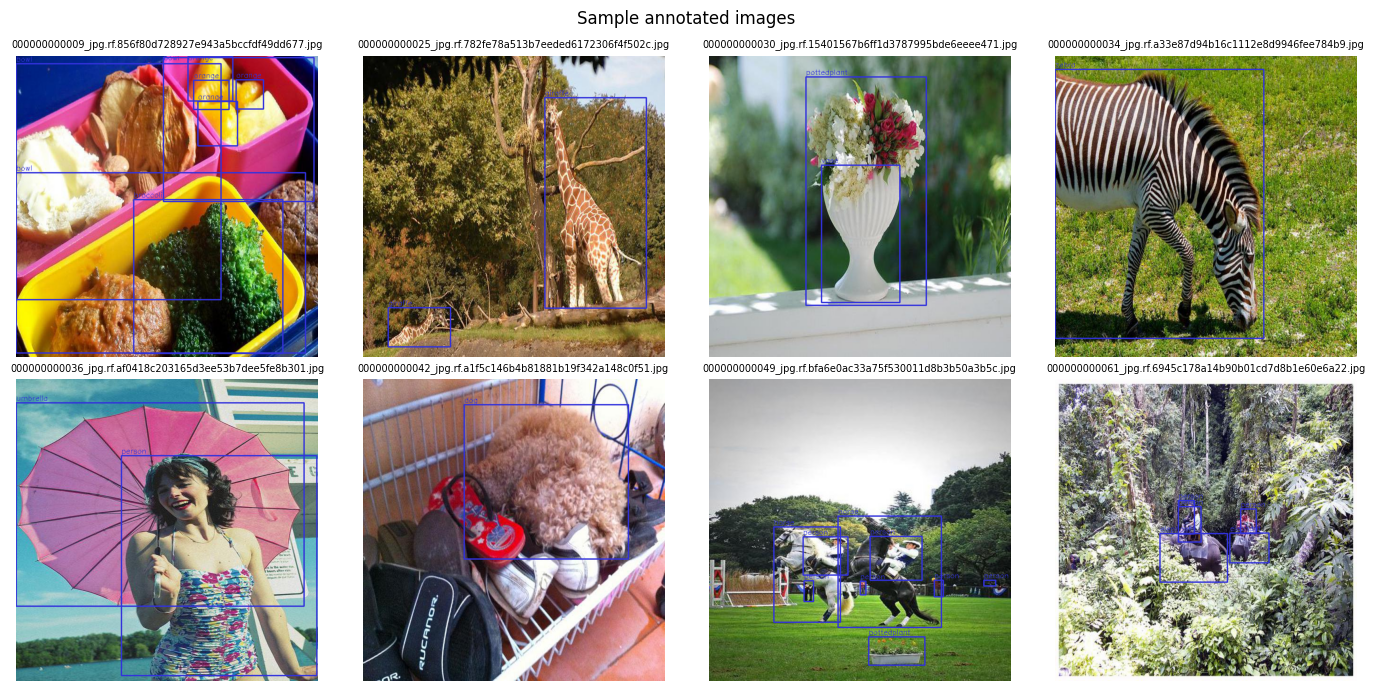

In [ ]:
# ── Visualise 8 annotated training images ────────────────────────────────────

def draw_yolo_labels(img_path, label_path, class_names):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id          = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])
            x1 = int((xc - bw/2) * W);  y1 = int((yc - bh/2) * H)
            x2 = int((xc + bw/2) * W);  y2 = int((yc + bh/2) * H)
            color = (220, 50, 50) if cls_id == 0 else (50, 50, 220)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, class_names[cls_id], (x1, max(y1-5, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img

img_paths = sorted((DATA_ROOT / 'train'/'images' ).glob('*.jpg'))[:8]
lbl_paths = [DATA_ROOT / 'train' /'labels' / p.with_suffix('.txt').name for p in img_paths]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, ip, lp in zip(axes.flatten(), img_paths, lbl_paths):
    ax.imshow(draw_yolo_labels(ip, lp, CLASS_NAMES))
    ax.set_title(ip.name, fontsize=7)
    ax.axis('off')
plt.suptitle('Sample annotated images', fontsize=12)
plt.tight_layout(); plt.show()


---

# PART E — Train YOLO on the Custom Dataset

## Part E.1 — Model Selection

We use **YOLOv8n** (nano), the smallest variant — fast to train on Colab.

| Model   | Parameters | Use case |
|---------|-----------|----------|
| yolov8n | 3.2 M     | Prototyping, Colab |
| yolov8s | 11.2 M    | Small datasets |
| yolov8m | 25.9 M    | Balanced speed/accuracy |
| yolov8l | 43.7 M    | Accuracy-first |
| yolov8x | 68.2 M    | Maximum accuracy |

In Lecture 3, you learned that YOLO is a **single-stage detector**: it divides
the image into a grid, and each cell predicts bounding boxes, confidence scores,
and class probabilities in a single forward pass. YOLOv8 extends this with a
modern anchor-free architecture.


In [ ]:
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')   # downloads weights on first run
print(yolo_model.info())


YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
(129, 3157200, 0, 8.8575488)


## Part E.2 — Train


In [ ]:
YAML_PATH   = str((DATA_ROOT / 'data.yaml').resolve())
PROJECT_DIR = 'data589_lab2'
RUN_NAME    = 'yolo_custom_v1'

train_results = yolo_model.train(
    data      = YAML_PATH,
    epochs    = 30,
    imgsz     = 416,
    batch     = 16,
    project   = PROJECT_DIR,
    name      = RUN_NAME,
    device    = 0 if torch.cuda.is_available() else 'cpu',
    exist_ok  = True,
)
print('Training complete.')


Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/COCO-128-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_custom_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

## Part E.3 — Inspect Training Curves

After training, Ultralytics saves a `results.png` in the run directory.


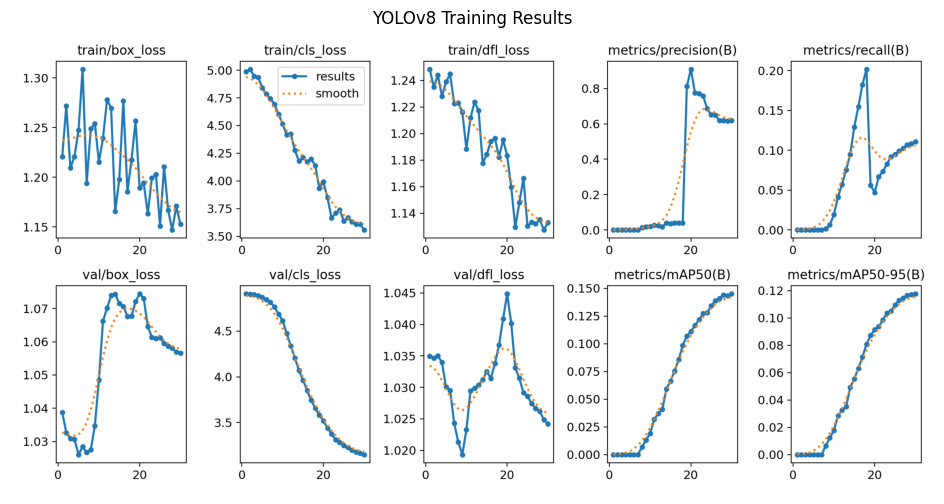

In [ ]:
run_dir     = Path('runs/detect') / PROJECT_DIR / RUN_NAME
results_png = run_dir / 'results.png'

if results_png.exists():
    from PIL import Image as PILImage
    plt.figure(figsize=(14, 6))
    plt.imshow(PILImage.open(results_png))
    plt.axis('off'); plt.title('YOLOv8 Training Results'); plt.show()
else:
    print('results.png not found — available files:', list(run_dir.iterdir()))

---

# PART F — Evaluate the YOLO Model

## Part F.1 — Validation Metrics


In [ ]:
best_weights = run_dir / 'weights' / 'best.pt'
yolo_eval    = YOLO(str(best_weights))

val_metrics = yolo_eval.val(
    data     = YAML_PATH,
    imgsz    = 416, # image resize to 416x416
    project  = PROJECT_DIR,
    name     = RUN_NAME + '_val',
    exist_ok = True,
)

print('\n── Validation Metrics ──────────────────────────────')
print(f'  mAP50      : {val_metrics.box.map50:.4f}')
print(f'  mAP50-95   : {val_metrics.box.map:.4f}')
print(f'  Precision  : {val_metrics.box.mp:.4f}')
print(f'  Recall     : {val_metrics.box.mr:.4f}')


Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,074,765 parameters, 0 gradients, 8.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1434.1±332.6 MB/s, size: 46.9 KB)
val: Scanning /content/COCO-128-2/valid/labels.cache... 123 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 36.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.3it/s 3.4s
                   all        123        904      0.623      0.111      0.146      0.119
             aeroplane          5          6      0.139      0.667      0.634      0.584
              backpack          4          6          0          0          0          0
                banana          1          1          1          0     0.0243     0.0194
          baseball bat          4          4          1          0          0          0
        baseball glove          4          7    

### Task F.1 — Metrics Interpretation

Fill in the table with your actual results:

| Metric | Your value | What it means |
|--------|-----------|---------------|
| mAP50     | 0.1458 | The model has low detection performance even at a loose IoU threshold (0.5), meaning it struggles to correctly detect and localize many objects |
| mAP50-95  | 0.1185 | Performance drops further at stricter IoU thresholds, indicating that bounding box localization is not very precise. |
| Precision | 0.6232 | When the model predicts an object, it is often correct (relatively few false positives) |
| Recall    | 0.1112 | The model misses most objects in the dataset (many false negatives). |

Then answer:

1. What does it mean if mAP50 is high but mAP50-95 is much lower?
2. A detector with high Precision but low Recall — in which scenario would you prefer this?
3. What single change would you make first to improve mAP50?

**Your answers:**
1. It means the model can generally detect objects at a loose overlap threshold, but its bounding boxes are not very accurate. As the IoU threshold becomes stricter, performance drops because the predicted boxes do not align well with the ground truth.

2. This is preferred in scenarios where false positives are costly or dangerous. For example, in medical diagnosis or fraud detection, it is better to only make predictions when the model is very confident, even if it misses some cases.

3. The first change would be to train the model for more epochs (e.g., increase from 30 to 50–100 epochs), so it has more time to learn patterns and improve detection performance.

## Part F.2 — Run Inference on Test Images


In [ ]:
predictions = yolo_eval.predict(
    source   = str(DATA_ROOT / 'test' / 'images'),
    conf     = 0.25,
    iou      = 0.45,
    save     = True,
    project  = PROJECT_DIR,
    name     = RUN_NAME + '_infer',
    exist_ok = True,
)
print(f'Ran inference on {len(predictions)} images.')



image 1/127 /content/COCO-128-2/test/images/000000000009_jpg.rf.6acc173402df5523069e146edb03ff4b.jpg: 416x416 (no detections), 7.4ms
image 2/127 /content/COCO-128-2/test/images/000000000025_jpg.rf.ed74f70d3b9ede1832934740b7ac60c7.jpg: 416x416 1 giraffe, 7.4ms
image 3/127 /content/COCO-128-2/test/images/000000000030_jpg.rf.9b6a40cdb2346d232072517b865b4846.jpg: 416x416 (no detections), 7.7ms
image 4/127 /content/COCO-128-2/test/images/000000000034_jpg.rf.b518abdaed199dcb88854cf20fce8078.jpg: 416x416 1 zebra, 6.1ms
image 5/127 /content/COCO-128-2/test/images/000000000036_jpg.rf.236f23e769287f9219fc898a1ab9e716.jpg: 416x416 1 person, 6.8ms
image 6/127 /content/COCO-128-2/test/images/000000000042_jpg.rf.49cb642017295e9511dadffcbc1f3d82.jpg: 416x416 (no detections), 6.4ms
image 7/127 /content/COCO-128-2/test/images/000000000049_jpg.rf.0760da738de18a89ab16281e2ce8b5ba.jpg: 416x416 2 persons, 6.3ms
image 8/127 /content/COCO-128-2/test/images/000000000061_jpg.rf.8404fd66d32c0df0f82c74eaa4f3f2d

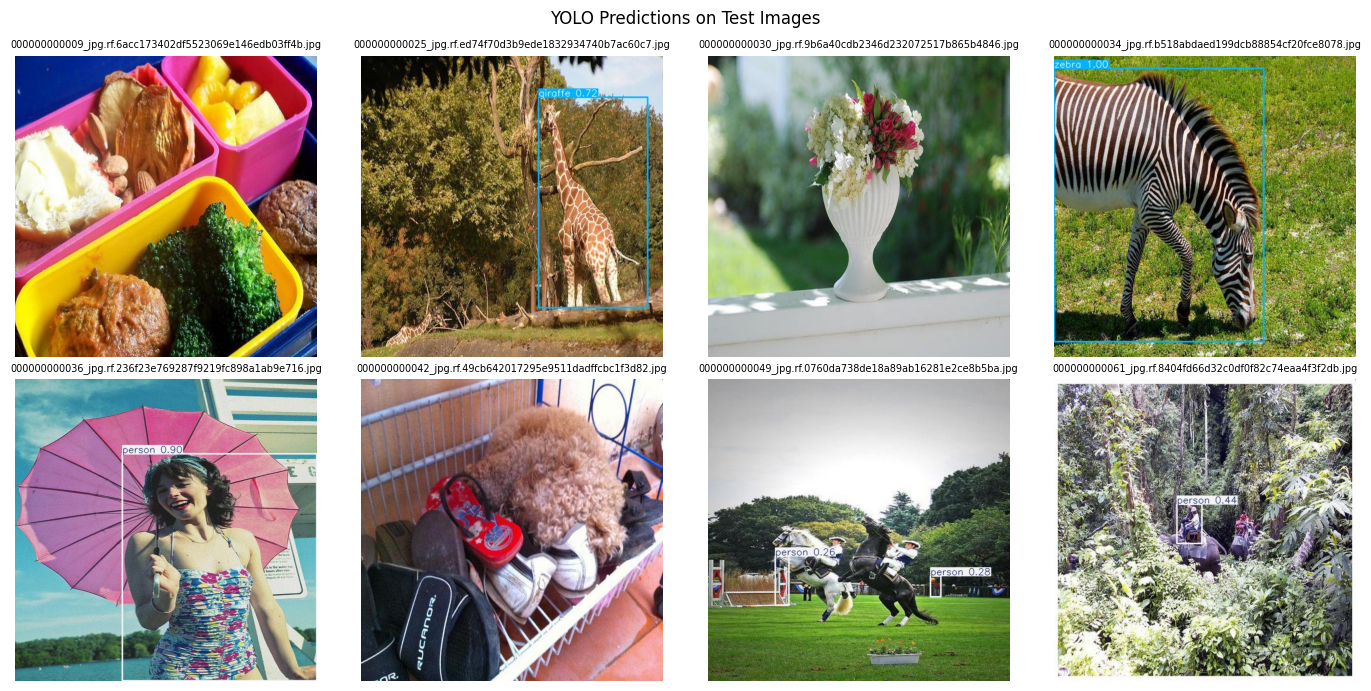

In [ ]:
# Display first 8 prediction images
pred_dir  = Path('runs/detect') / PROJECT_DIR / (RUN_NAME + '_infer') #The ultralytics library saves its results in a runs/detect subfolder within your project directory.
pred_imgs = sorted(pred_dir.glob('*.jpg'))[:8]

if pred_imgs:
    from PIL import Image as PILImage
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, p in zip(axes.flatten(), pred_imgs):
        ax.imshow(np.array(PILImage.open(p)))
        ax.set_title(p.name, fontsize=7); ax.axis('off')
    plt.suptitle('YOLO Predictions on Test Images', fontsize=12)
    plt.tight_layout(); plt.show()
else:
    print('No prediction images found at', pred_dir)

---

# PART G — Final Reflection

Answer both questions below using **3–5 sentences** each.

---

### G.1 — CNN vs Fully-Connected Network

Explain why a CNN is better suited to image data than a fully-connected network.
Reference **local connectivity**, **weight sharing**, and **translation invariance**
from the lecture.

**Your answer:**
A CNN is better suited for image data because it uses local connectivity, meaning each neuron only looks at a small region of the image, allowing it to capture spatial features like edges and textures. It also uses weight sharing, where the same filter is applied across different parts of the image, significantly reducing the number of parameters and improving efficiency. Additionally, CNNs provide translation invariance, meaning they can recognize objects even if they appear in different positions within the image. In contrast, fully-connected networks treat all pixels independently and ignore spatial structure, making them less efficient and less effective for image tasks.

---

### G.2 — YOLO vs Faster R-CNN

What is the key architectural difference between a one-stage and a two-stage detector?
When would you choose Faster R-CNN over YOLO?

**Your answer:**
The key architectural difference is that YOLO is a one-stage detector, meaning it directly predicts bounding boxes and class probabilities in a single pass, making it very fast. Faster R-CNN is a two-stage detector, where the first stage generates region proposals and the second stage classifies them, resulting in higher accuracy but slower performance. You would choose Faster R-CNN when accuracy is more important than speed, such as in medical imaging or detailed object detection tasks. YOLO is preferred for real-time applications like video processing where speed is critical.


---

## Submission Checklist

- [ ] **B.1** — Three concept-check questions answered
- [ ] **B.2** — `conv_output_size` implemented; all three tests pass
- [ ] **B.4** — `CNN` class implemented; `(2, 10)` output confirmed
- [ ] **B.5** — CIFAR-10 batch displayed
- [ ] **B.6** — `train_one_epoch` and `evaluate` completed
- [ ] **B.7** — CNN trained for 5 epochs; per-epoch log visible
- [ ] **B.8** — Loss/accuracy curves and confusion matrix displayed; reflection answered
- [ ] **C.1** — `compute_iou` implemented; all tests pass
- [ ] **C.3** — TP, FP, FN, Precision, Recall computed
- [ ] **D** — Roboflow dataset downloaded; structure verified
- [ ] **E** — YOLO trained for 30 epochs; training curves displayed
- [ ] **F.1** — Validation metrics reported and interpreted
- [ ] **F.2** — Inference predictions displayed
- [ ] **G** — Both reflection questions answered

> **Good luck!**
